In [17]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import Field

In [18]:
load_dotenv()

True

In [19]:
model = ChatGroq(model='openai/gpt-oss-120b')

In [20]:
class SubState(TypedDict):
    input_text: str
    hindi_text: str

In [21]:
def hindi_translator(state: SubState):
    prompt = f"""You are a helpful assistant please translate the input text
    into hindi text, Do not add any extra content. Just translate naturally
    input_text: {state['input_text']}"""

    result = model.invoke(prompt).content
    return {'hindi_text': result}


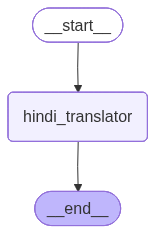

In [22]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('hindi_translator', hindi_translator)

subgraph_builder.add_edge(START, 'hindi_translator')
subgraph_builder.add_edge('hindi_translator', END)

subgraph = subgraph_builder.compile()

subgraph

In [23]:
class ParentState(TypedDict):
    topic: str
    generate_eng: str
    translate_hindi: str

In [29]:
def generate_eng(state: ParentState):
    prompt = f"""You are a helpful assistant please explain the given topic carefully
    topic: {state['topic']}
    """
    result = model.invoke(prompt).content

    return {'generate_eng': result}


In [38]:
def translate_hindi(state: ParentState):
    input_text = state['generate_eng']
    result = subgraph.invoke({'input_text': state['generate_eng']})

    return {'translate_hindi': result}

In [39]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node('generate_eng', generate_eng)
parent_builder.add_node('translate_hindi', translate_hindi)

parent_builder.add_edge(START, 'generate_eng')
parent_builder.add_edge('generate_eng', 'translate_hindi')
parent_builder.add_edge('translate_hindi', END)

parentGraph = parent_builder.compile()


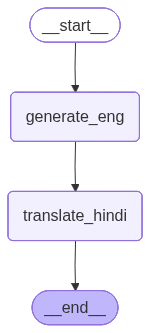

In [40]:
parentGraph

In [41]:
initial_state = {'topic': 'AI future'}
final_state = parentGraph.invoke(initial_state)

In [42]:
final_state

{'topic': 'AI future',
 'generate_eng': '## The Future of Artificial Intelligence: A Careful Overview  \n\n### 1.\u202fWhy the Future of AI Matters  \nArtificial Intelligence (AI) is already reshaping how we work, learn, create, and interact. Understanding where it is headed helps individuals, businesses, policymakers, and societies prepare for opportunities **and** challenges—ranging from economic growth to ethical dilemmas and governance needs.\n\n---\n\n## 2.\u202fKey Technological Trajectories  \n\n| Trend | What It Means | Current State (2024) | Expected Milestones (2025‑2035) |\n|-------|----------------|----------------------|--------------------------------|\n| **Foundation Models & Large‑Scale Pre‑training** | Massive neural networks (e.g., GPT‑4, PaLM‑2) trained on diverse data, then fine‑tuned for specific tasks. | Widely used for chat, coding assistants, content generation. | Models with trillions of parameters that can reason across domains, with “self‑supervised” continua